# Diff-Image Displacement Predictor
Given two 224×224 RGB frames, predict `(Δx, Δy, Δcx, Δcy, Δarea)`: net xy displacement in mm, plus
the change in the Newton-ring centroid (px) and area (px²).

**Data**: HDF5 files `data/robot_*.hdf5`
- `frame_i_x` — `(224, 224, 3)` uint8 BGR frame
- `frame_i_y` — `(3,)` float32 motor position `[x, y, z]` in mm
- `frame_i_ring` — `(3,)` float32 `[cx, cy, area]` Newton-ring feature (NaN if no ring found; see
  `newton_rings.ipynb`)

**Target**: `[Δx, Δy, Δcx, Δcy, Δarea]` between two frames from the same episode. Raw `Δz` is
dropped — z carries no reliable signal in the raw pixels, but the Newton ring (visible when z is
low) shrinks/grows and its centroid shifts as z changes, so the ring features stand in for z.

**Hypothesis**: the background is mostly static; the only thing that actually moves between
frames is a translucent film. Rather than asking a ViT to implicitly learn to subtract two
embeddings, we hand it the subtraction directly: blur each frame (to suppress sensor noise), then
subtract, and feed the resulting diff image into a small, randomly-initialized ("blank", not
pretrained) ViT.

**Architecture**:
```
frame_i ─ gaussian blur (σ fixed) ─┐
                                    ├─ diff = blur(frame_j) − blur(frame_i) ─ blank ViT (6 layers, hidden=192) ─ CLS token (192,)
frame_j ─ gaussian blur (σ fixed) ─┘

displacement = MLP(CLS token) → (5,)     [head has <100k params]
```
The ViT is not pretrained — it's trained from scratch end-to-end on diff images, since a
pretrained-on-natural-images encoder (like DINO) has never seen difference images and has no
reason to represent them well. The CLS token is regularized with SigReg (a variance/hinge loss) to
prevent it from collapsing to a constant while training jointly with the narrow regression loss.

**Target normalization**: all 5 components (`Δx, Δy, Δcx, Δcy, Δarea`) are independently z-scored
(mean/std computed from sampled pairs) — this adapts to each dimension's actual spread rather than
relying on a fixed guessed scale, which matters most for `Δarea` since its range can vary a lot
across episodes.

**Loss**: `Huber(pred, target) + λ · SigReg(cls_token)`.

### Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

! pip install -q transformers h5py

In [ ]:
import h5py
import multiprocessing
import warnings
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from transformers import ViTModel, ViTConfig

multiprocessing.set_start_method('fork', force=True)
warnings.filterwarnings('ignore')

# ── paths ─────────────────────────────────────────────────────────────────
CKPT_DIR = Path('/content/drive/MyDrive/transfer_stacking_data/checkpoints_diff_pred')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'device: {device}')

device: mps


## Data
### Load episode positions

In [ ]:
HDF5_DIR   = Path('/content/drive/MyDrive/transfer_stacking_data/hdf5')
HDF5_FILES = sorted(HDF5_DIR.glob('robot_*.hdf5'))
assert HDF5_FILES, f'No robot_*.hdf5 files found in {HDF5_DIR}'
assert len(HDF5_FILES) >= 2, 'Need at least 2 hdf5 files to hold one out for validation'

IMG_SIZE = 224

# Hold out the last file (by sorted filename) entirely as a validation episode —
# its frames are never sampled during training.
TRAIN_FILES = HDF5_FILES[:-1]
VAL_FILES   = HDF5_FILES[-1:]
print(f'Train files: {[p.name for p in TRAIN_FILES]}')
print(f'Val file   : {[p.name for p in VAL_FILES]}')


def load_episode_data(files):
    episode_data = []
    for path in files:
        with h5py.File(path, 'r') as f:
            n = sum(1 for k in f.keys() if k.endswith('_x'))
            xyz = torch.from_numpy(
                np.stack([f[f'frame_{i}_y'][:] for i in range(n)]).astype(np.float32)
            )  # (n, 3)
            ring = np.stack([
                f[f'frame_{i}_ring'][:] if f'frame_{i}_ring' in f else np.full(3, np.nan, dtype=np.float32)
                for i in range(n)
            ]).astype(np.float32)
            ring = torch.from_numpy(ring)  # (n, 3) [cx, cy, area], NaN where no ring was found

        # A "no ring found" frame has a well-defined area (0) but no meaningful centroid — keep
        # cx/cy as NaN (masked out per-pair in the dataset) and zero only the area column.
        ring_found = ~torch.isnan(ring).any(dim=1)
        ring[~ring_found, 2] = 0.0

        episode_data.append({'path': str(path), 'n': n, 'xyz': xyz, 'ring': ring, 'ring_found': ring_found})
        print(f'{path.name}: {n} frames  xyz range [{xyz.min():.1f}, {xyz.max():.1f}] mm  '
              f'ring found {ring_found.sum().item()}/{n}')
    return episode_data


print('\nTrain episodes:')
episode_data = load_episode_data(TRAIN_FILES)
print('\nVal episodes:')
val_episode_data = load_episode_data(VAL_FILES)

print(f'\nTrain total : {sum(ep["n"] for ep in episode_data):,} frames')
print(f'Val total   : {sum(ep["n"] for ep in val_episode_data):,} frames')

Train files: ['robot_1.hdf5', 'robot_2.hdf5', 'robot_3.hdf5', 'robot_4.hdf5', 'robot_5.hdf5', 'robot_6.hdf5', 'robot_7.hdf5']
Val file   : ['robot_8.hdf5']

Train episodes:
robot_1.hdf5: 4663 frames  xyz range [4.1, 6.8] mm  ring found 3191/4663
robot_2.hdf5: 5911 frames  xyz range [4.4, 6.7] mm  ring found 5389/5911
robot_3.hdf5: 1820 frames  xyz range [4.7, 6.7] mm  ring found 1651/1820
robot_4.hdf5: 2570 frames  xyz range [4.5, 6.9] mm  ring found 1194/2570
robot_5.hdf5: 8177 frames  xyz range [4.6, 6.9] mm  ring found 5723/8177
robot_6.hdf5: 5848 frames  xyz range [4.7, 6.7] mm  ring found 4124/5848
robot_7.hdf5: 7279 frames  xyz range [4.4, 6.4] mm  ring found 5447/7279

Val episodes:
robot_8.hdf5: 5676 frames  xyz range [4.3, 6.5] mm  ring found 3436/5676

Train total : 36,268 frames
Val total   : 5,676 frames


### Dataset
Each item samples two random frames `(i, j)` from the **same episode** (any frame, ring found or
not) and returns:
- `frame_i`, `frame_j`: `(3, H, W)` uint8
- `target`: `[Δx, Δy, Δcx, Δcy, Δarea]`, raw (un-normalized) units (mm, mm, px, px, px²) — `Δcx/Δcy`
  are `0` (dummy) when either frame has no detected ring, since there's no centroid to diff
- `mask`: `(5,)` — `1` for `Δx, Δy, Δarea` always; `1` for `Δcx, Δcy` only if **both** `i` and `j`
  have a detected ring, else `0`

In [4]:
class PairDisplacementDataset(Dataset):
    """Random pairs (frame_i, frame_j) from the same episode — any frame, ring found or not.

    Target: [Δx, Δy, Δcx, Δcy, Δarea] = concat(xyz[j, :2] - xyz[i, :2], ring[j] - ring[i]),
    raw units (mm, mm, px, px, px²). Δarea is always well-defined (0 area when no ring). Δcx/Δcy
    are dummy 0s and masked out (via the returned `mask`) whenever either frame has no detected
    ring. Frames are lazy-loaded from HDF5 per __getitem__.
    """

    def __init__(self, episode_data):
        self.episodes = episode_data
        self.ep_ends  = []
        total = 0
        for ep in episode_data:
            total += ep['n']
            self.ep_ends.append(total)
        self.total = total

    def __len__(self):
        return self.total

    def _ep_of(self, idx):
        for k, end in enumerate(self.ep_ends):
            if idx < end:
                return k
        return len(self.ep_ends) - 1

    def _read_frame(self, path, frame_idx):
        with h5py.File(path, 'r') as f:
            bgr = f[f'frame_{frame_idx}_x'][:]       # (H, W, 3) uint8 BGR
        rgb = bgr[:, :, ::-1].copy()
        return torch.from_numpy(rgb).permute(2, 0, 1)  # (3, H, W) uint8

    def __getitem__(self, idx):
        k        = self._ep_of(idx)
        ep       = self.episodes[k]
        n        = ep['n']
        prev_end = self.ep_ends[k - 1] if k > 0 else 0
        i        = idx - prev_end
        j        = torch.randint(0, n, (1,)).item()

        frame_i = self._read_frame(ep['path'], i)
        frame_j = self._read_frame(ep['path'], j)

        delta_xy   = ep['xyz'][j, :2] - ep['xyz'][i, :2]   # (2,) mm
        delta_area = ep['ring'][j, 2:3] - ep['ring'][i, 2:3]   # (1,) px²

        cxcy_valid = bool(ep['ring_found'][i] and ep['ring_found'][j])
        if cxcy_valid:
            delta_cxcy = ep['ring'][j, :2] - ep['ring'][i, :2]   # (2,) px
        else:
            delta_cxcy = torch.zeros(2)   # dummy, masked out below

        target = torch.cat([delta_xy, delta_cxcy, delta_area])                 # (5,)
        mask   = torch.tensor([1., 1., float(cxcy_valid), float(cxcy_valid), 1.])
        return frame_i, frame_j, target, mask


dataset     = PairDisplacementDataset(episode_data)
loader      = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, drop_last=True)
print(f'Train dataset size: {len(dataset):,} pairs/epoch')

val_dataset = PairDisplacementDataset(val_episode_data)
val_loader  = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, drop_last=False)
print(f'Val dataset size  : {len(val_dataset):,} pairs')

Train dataset size: 36,268 pairs/epoch
Val dataset size  : 5,676 pairs


## Model

**Blur + diff**: each frame is blurred with a fixed-σ Gaussian (depthwise conv2d, applied on-device
to a whole batch at once) before subtracting, to suppress per-pixel sensor noise that would
otherwise dominate the raw difference.

**Encoder (blank, fully trainable)**: a small randomly-initialized ViT (`hidden_size=192`,
6 layers, 3 heads) — not pretrained, since it needs to learn to represent *difference* images from
scratch. Takes the diff image directly; its CLS token (`last_hidden_state[:, 0]`) is the 192-dim
embedding.

**Head** (<100k params): a small MLP directly on the CLS token → `(3,)`.

In [7]:
EMB_DIM    = 192    # blank ViT hidden size == CLS token dim
BLUR_SIGMA = 2.0     # fixed gaussian blur sigma applied to each frame before subtraction
TARGET_DIM = 5        # [Δx, Δy, Δcx, Δcy, Δarea]


def make_gaussian_kernel(sigma: float, device: str):
    """(1, 1, k, k) normalized 2D gaussian kernel, k = 2*round(3*sigma)+1."""
    if sigma <= 0:
        return None
    radius = max(1, int(round(3 * sigma)))
    coords = torch.arange(-radius, radius + 1, dtype=torch.float32, device=device)
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel_2d = torch.outer(g, g)
    kernel_2d = kernel_2d / kernel_2d.sum()
    return kernel_2d.view(1, 1, kernel_2d.shape[0], kernel_2d.shape[1])


def gaussian_blur(x: torch.Tensor, kernel: torch.Tensor | None) -> torch.Tensor:
    """(B, C, H, W) -> (B, C, H, W), blurred per-channel (depthwise conv, same padding)."""
    if kernel is None:
        return x
    c = x.shape[1]
    k = kernel.repeat(c, 1, 1, 1).to(dtype=x.dtype, device=x.device)
    pad = k.shape[-1] // 2
    return F.conv2d(x, k, padding=pad, groups=c)


_blur_kernel = make_gaussian_kernel(BLUR_SIGMA, device)

vit_cfg = ViTConfig(
    num_channels=3, image_size=IMG_SIZE, patch_size=16,
    hidden_size=EMB_DIM, num_hidden_layers=6,
    num_attention_heads=3, intermediate_size=768,
)
vit = ViTModel(vit_cfg, add_pooling_layer=False).to(device)
vit.train()   # randomly initialized ('blank'), fully trainable

n_vit = sum(p.numel() for p in vit.parameters())
print(f'ViT params (all trainable, randomly initialized): {n_vit:,}')


def to_float(x):
    """(B, 3, H, W) uint8 -> (B, 3, H, W) float32 [0,1] on device."""
    return x.to(device, dtype=torch.float32).div_(255.0)


def extract_embedding(frame_i_float, frame_j_float):
    """(B, 3, 224, 224) float32 [0,1] x2 -> (B, EMB_DIM) CLS token of the blank ViT run on
    the blurred difference image blur(frame_j) - blur(frame_i).
    """
    bi = gaussian_blur(frame_i_float, _blur_kernel)
    bj = gaussian_blur(frame_j_float, _blur_kernel)
    diff = bj - bi                                          # (B, 3, H, W), range ~[-1, 1]
    hidden = vit(diff, interpolate_pos_encoding=False).last_hidden_state
    return hidden[:, 0]                                      # (B, EMB_DIM) CLS token


class DisplacementHead(nn.Module):
    """CLS token -> small MLP -> (5,): [Δx, Δy, Δcx, Δcy, Δarea]. Kept under a 100k-param budget."""

    def __init__(self, emb_dim=EMB_DIM, target_dim=TARGET_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, 256),
            nn.SiLU(),
            nn.Linear(256, target_dim),
        )

    def forward(self, emb):
        return self.net(emb)


def sigreg_loss(emb, gamma=1.0, eps=1e-4):
    """Variance/'sigreg' hinge loss: penalize embedding dimensions whose batch-wise std
    falls below gamma, to prevent representation collapse while training the encoder.
    """
    std = torch.sqrt(emb.var(dim=0) + eps)
    return F.relu(gamma - std).mean()


head = DisplacementHead(emb_dim=EMB_DIM, target_dim=TARGET_DIM).to(device)
n_head = sum(p.numel() for p in head.parameters())
print(f'Head params (trainable): {n_head:,}')
assert n_head <= 100_000, f'head has {n_head:,} params, exceeds the 100k budget'

with torch.no_grad():
    _fi   = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=device)
    _fj   = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=device)
    _emb  = extract_embedding(_fi, _fj)
    _out  = head(_emb)
    print(f'Embedding shape : {_emb.shape}')   # expect (2, 192)
    print(f'Output shape    : {_out.shape}')   # expect (2, 5)

ViT params (all trainable, randomly initialized): 2,855,232
Head params (trainable): 51,077
Embedding shape : torch.Size([2, 192])
Output shape    : torch.Size([2, 5])


In [5]:
# Compute per-axis mean and std for all 5 target dims (Δx, Δy, Δcx, Δcy, Δarea), from random pairs
# — same distribution as training. Δx, Δy, Δarea are sampled from all frames; Δcx, Δcy stats are
# computed only from pairs where both frames have a detected ring (the same set the training loss
# ends up seeing for those two dims, via the mask).
_rng = torch.Generator()
_rng.manual_seed(100)
_samples_xy_area = []
_samples_cxcy    = []
for ep in episode_data:
    xyz        = ep['xyz']          # (n, 3)
    ring       = ep['ring']         # (n, 3)
    ring_found = ep['ring_found']   # (n,)
    n = ep['n']

    i_idx = torch.randint(0, n, (2000,), generator=_rng)
    j_idx = torch.randint(0, n, (2000,), generator=_rng)
    delta_xy   = xyz[j_idx, :2] - xyz[i_idx, :2]
    delta_area = ring[j_idx, 2:3] - ring[i_idx, 2:3]
    _samples_xy_area.append(torch.cat([delta_xy, delta_area], dim=1))   # (2000, 3)

    valid_idx = torch.nonzero(ring_found, as_tuple=True)[0]
    m = len(valid_idx)
    ci_idx = valid_idx[torch.randint(0, m, (2000,), generator=_rng)]
    cj_idx = valid_idx[torch.randint(0, m, (2000,), generator=_rng)]
    _samples_cxcy.append(ring[cj_idx, :2] - ring[ci_idx, :2])           # (2000, 2)

_samples_xy_area = torch.cat(_samples_xy_area, dim=0)   # (N, 3): Δx, Δy, Δarea
_samples_cxcy    = torch.cat(_samples_cxcy, dim=0)      # (N, 2): Δcx, Δcy

_mean_xy_area = _samples_xy_area.mean(0)
_std_xy_area  = _samples_xy_area.std(0).clamp(min=1e-3)
_mean_cxcy    = _samples_cxcy.mean(0)
_std_cxcy     = _samples_cxcy.std(0).clamp(min=1e-3)

# Reassemble into (5,) [Δx, Δy, Δcx, Δcy, Δarea] order.
delta_mean = torch.cat([_mean_xy_area[:2], _mean_cxcy, _mean_xy_area[2:]]).to(device)
delta_std  = torch.cat([_std_xy_area[:2],  _std_cxcy,  _std_xy_area[2:]]).to(device)

AXIS_NAMES  = ['x', 'y', 'cx', 'cy', 'area']
AXIS_UNITS  = ['mm', 'mm', 'px', 'px', 'px²']

print('Target stats from random pairs:')
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    print(f'  {name}: mean={delta_mean[i]:.3f}  std={delta_std[i]:.3f} {unit}')


def normalize_target(target):
    """(B, 5) raw [Δx, Δy, Δcx, Δcy, Δarea] -> (B, 5) z-scored."""
    return (target - delta_mean) / delta_std


def denormalize_target(pred):
    """(B, 5) z-scored -> (B, 5) raw [Δx, Δy, Δcx, Δcy, Δarea]."""
    return pred * delta_std + delta_mean

Target stats from random pairs:
  x: mean=-0.000  std=0.089 mm
  y: mean=-0.001  std=0.141 mm
  cx: mean=0.008  std=1.356 px
  cy: mean=0.146  std=13.124 px
  area: mean=13.029  std=6332.910 px²


## Training
The whole ViT is trainable (it starts from random init, so there's nothing to preserve by
freezing), and is optimized jointly with the head.

In [ ]:
STARTING_EPOCH = 0
NUM_EPOCHS     = 50
SIGREG_WEIGHT  = 0.05
SIGREG_GAMMA   = 1.0

optimizer = torch.optim.AdamW([
    {'params': vit.parameters(),  'lr': 1e-4},   # trained from scratch — needs a real LR
    {'params': head.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


def masked_huber(pred, target_norm, mask, delta=1.0):
    """Elementwise Huber loss, masked and averaged only over valid (mask==1) entries."""
    elementwise = F.huber_loss(pred, target_norm, delta=delta, reduction='none')
    return (elementwise * mask).sum() / mask.sum().clamp(min=1.0)


def masked_abs_error_sum(pred_raw, target, mask):
    """Returns (sum of |error| per axis, count of valid entries per axis) for masked accumulation."""
    abs_err = (pred_raw - target).abs() * mask
    return abs_err.sum(dim=0).cpu(), mask.sum(dim=0).cpu()


def run_validation():
    vit.eval()
    head.eval()
    losses = []
    err_sum   = torch.zeros(5)
    err_count = torch.zeros(5)
    with torch.no_grad():
        for frame_i, frame_j, target, mask in val_loader:
            frame_i    = to_float(frame_i)
            frame_j    = to_float(frame_j)
            target     = target.to(device)
            mask       = mask.to(device)
            target_norm = normalize_target(target)

            emb  = extract_embedding(frame_i, frame_j)
            pred = head(emb)
            loss = masked_huber(pred, target_norm, mask)

            pred_raw = denormalize_target(pred)
            e_sum, e_cnt = masked_abs_error_sum(pred_raw, target, mask)
            err_sum += e_sum; err_count += e_cnt
            losses.append(loss.item())
    vit.train()
    head.train()
    return float(np.mean(losses)), err_sum / err_count.clamp(min=1.0)


vit.train()
head.train()

for epoch in range(STARTING_EPOCH, NUM_EPOCHS):
    losses, sigreg_losses = [], []
    train_err_sum   = torch.zeros(5)
    train_err_count = torch.zeros(5)

    for frame_i, frame_j, target, mask in tqdm(loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=False):
        frame_i     = to_float(frame_i)
        frame_j     = to_float(frame_j)
        target      = target.to(device)
        mask        = mask.to(device)
        target_norm = normalize_target(target)

        emb  = extract_embedding(frame_i, frame_j)
        pred = head(emb)                                       # (B, 5) normalised
        huber = masked_huber(pred, target_norm, mask)
        sreg  = sigreg_loss(emb, gamma=SIGREG_GAMMA)
        loss  = huber + SIGREG_WEIGHT * sreg

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(vit.parameters()) + list(head.parameters()), max_norm=5.0)
        optimizer.step()

        pred_raw = denormalize_target(pred.detach())
        e_sum, e_cnt = masked_abs_error_sum(pred_raw, target, mask)
        train_err_sum += e_sum; train_err_count += e_cnt
        losses.append(huber.item())
        sigreg_losses.append(sreg.item())

    scheduler.step()
    val_loss, val_abs_err = run_validation()
    train_abs_err = train_err_sum / train_err_count.clamp(min=1.0)
    train_err_str = '  '.join(f'{n}={train_abs_err[i]:.3f}{u}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
    val_err_str   = '  '.join(f'{n}={val_abs_err[i]:.3f}{u}' for i, (n, u) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)))
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}  '
          f'train_loss={np.mean(losses):.4f}  sigreg={np.mean(sigreg_losses):.4f}  '
          f'lr={scheduler.get_last_lr()[-1]:.2e}')
    print(f'  train|err|: {train_err_str}')
    print(f'  val_loss={val_loss:.4f}  val|err|: {val_err_str}')

    if (epoch + 1) % 10 == 0 or epoch + 1 == NUM_EPOCHS:
        torch.save({
            'epoch': epoch + 1,
            'vit': vit.state_dict(),
            'head': head.state_dict(),
            'delta_mean': delta_mean.cpu(),
            'delta_std': delta_std.cpu(),
        }, CKPT_DIR / f'diff_pred_epoch_{epoch+1:04d}.pt')

## Evaluation
### Load checkpoint

In [ ]:
ckpts = sorted(CKPT_DIR.glob('diff_pred_epoch_*.pt'))
if ckpts:
    ckpt = torch.load(ckpts[-1], map_location=device, weights_only=False)
    vit.load_state_dict(ckpt['vit'])
    head.load_state_dict(ckpt['head'])
    delta_mean = ckpt['delta_mean'].to(device)
    delta_std  = ckpt['delta_std'].to(device)
    print(f'Loaded: {ckpts[-1].name}  (epoch {ckpt["epoch"]})')
else:
    print('No checkpoints — run training first.')

vit.eval()
head.eval()

Loaded: diff_pred_epoch_0040.pt  (epoch 40)


DisplacementHead(
  (net): Sequential(
    (0): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=192, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=5, bias=True)
  )
)

### Per-axis error distribution

In [ ]:
all_preds, all_gt, all_mask = [], [], []

with torch.no_grad():
    for frame_i, frame_j, target, mask in tqdm(val_loader, desc='Evaluating'):
        frame_i = to_float(frame_i.to(device))
        frame_j = to_float(frame_j.to(device))
        emb = extract_embedding(frame_i, frame_j)
        pred_norm = head(emb)
        pred_raw  = denormalize_target(pred_norm).cpu()
        all_preds.append(pred_raw)
        all_gt.append(target)
        all_mask.append(mask)

all_preds = torch.cat(all_preds).numpy()
all_gt    = torch.cat(all_gt).numpy()
all_mask  = torch.cat(all_mask).numpy().astype(bool)
errors    = all_preds - all_gt

print('Per-axis MAE — held-out validation file (Δcx/Δcy computed only over pairs with a ring in both frames):')
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = all_mask[:, i]
    mae  = np.abs(errors[valid, i]).mean()
    rmse = np.sqrt((errors[valid, i] ** 2).mean())
    print(f'  {name}: MAE={mae:.3f} {unit}   RMSE={rmse:.3f} {unit}   (n={valid.sum()}/{len(valid)})')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = all_mask[:, i]
    ax  = axes[i]
    gt  = all_gt[valid, i]
    pr  = all_preds[valid, i]
    lim = max(np.abs(gt).max(), np.abs(pr).max()) * 1.05
    ax.scatter(gt, pr, s=2, alpha=0.3, color='steelblue', rasterized=True)
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.2, label='ideal')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'GT Δ{name} ({unit})'); ax.set_ylabel(f'Pred Δ{name} ({unit})')
    ax.set_title(f'Δ{name}  MAE={np.abs(errors[valid, i]).mean():.3f} {unit}')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Qualitative: displacement vs. a fixed reference frame, over time
One cell on a **training** episode, one on the **held-out validation** episode — same fixed-reference
comparison, so you can directly compare how well the trend is tracked in each.

Sequence eval:   0%|          | 0/4000 [00:00<?, ?it/s]

Step-wise MAE per axis — training file (Δcx/Δcy over steps with a ring in both frames only):
  x: 0.010 mm   (n=4000/4000)
  y: 0.005 mm   (n=4000/4000)
  cx: 0.213 px   (n=2529/4000)
  cy: 1.514 px   (n=2529/4000)
  area: 233.864 px²   (n=4000/4000)


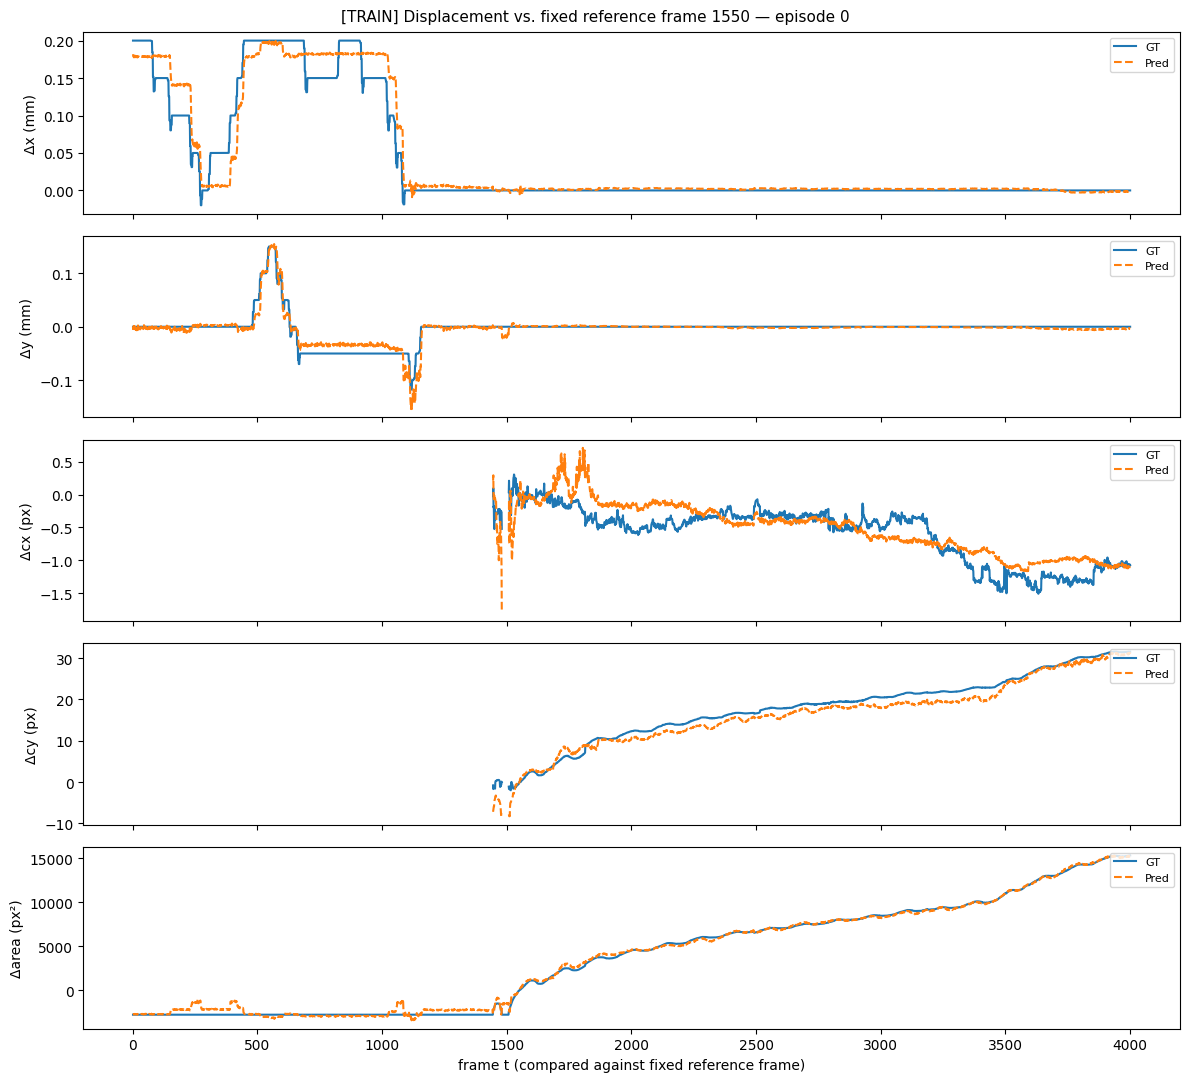

In [9]:
Q_EPISODE_DATA = episode_data   # TRAIN episode
EPISODE_IDX    = 0              # index into Q_EPISODE_DATA
REF_FRAME_IDX  = 1550              # fixed reference frame; every step compares frame t back to this one
N_STEPS        = 4000

ep = Q_EPISODE_DATA[EPISODE_IDX]
ref_found = bool(ep['ring_found'][REF_FRAME_IDX])
steps = list(range(1, min(N_STEPS, ep['n'] - 1) + 1))


def read(idx):
    with h5py.File(ep['path'], 'r') as f:
        bgr = f[f'frame_{idx}_x'][:]
    rgb = bgr[:, :, ::-1].copy()
    return to_float(torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).to(device))


all_preds_seq, all_gt_seq, all_mask_seq = [], [], []

with torch.no_grad():
    f_ref = read(REF_FRAME_IDX)
    for t in tqdm(steps, desc='Sequence eval'):
        ft       = read(t)
        emb      = extract_embedding(f_ref, ft)
        pred_raw = denormalize_target(head(emb)).squeeze(0).cpu().numpy()
        gt_xy    = (ep['xyz'][t, :2] - ep['xyz'][REF_FRAME_IDX, :2]).numpy()
        gt_ring  = (ep['ring'][t] - ep['ring'][REF_FRAME_IDX]).numpy()
        gt       = np.concatenate([gt_xy, gt_ring])
        cxcy_valid = ref_found and bool(ep['ring_found'][t])
        mask     = np.array([1., 1., float(cxcy_valid), float(cxcy_valid), 1.])
        all_preds_seq.append(pred_raw)
        all_gt_seq.append(gt)
        all_mask_seq.append(mask)

all_preds_seq = np.stack(all_preds_seq)
all_gt_seq    = np.stack(all_gt_seq)
all_mask_seq  = np.stack(all_mask_seq).astype(bool)

print('Step-wise MAE per axis — training file (Δcx/Δcy over steps with a ring in both frames only):')
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = all_mask_seq[:, i]
    mae = np.abs(all_preds_seq[valid, i] - all_gt_seq[valid, i]).mean()
    print(f'  {name}: {mae:.3f} {unit}   (n={valid.sum()}/{len(valid)})')

fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharex=True)
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = all_mask_seq[:, i]
    gt_plot   = np.where(valid, all_gt_seq[:, i], np.nan)
    pred_plot = np.where(valid, all_preds_seq[:, i], np.nan)
    axes[i].plot(steps, gt_plot,   label='GT',   lw=1.5)
    axes[i].plot(steps, pred_plot, label='Pred', lw=1.5, linestyle='--')
    axes[i].set_ylabel(f'Δ{name} ({unit})')
    axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('frame t (compared against fixed reference frame)')
plt.suptitle(f'[TRAIN] Displacement vs. fixed reference frame {REF_FRAME_IDX} — episode {EPISODE_IDX}', fontsize=11)
plt.tight_layout()
plt.show()

Sequence eval:   0%|          | 0/4000 [00:00<?, ?it/s]

Step-wise MAE per axis — held-out validation file (Δcx/Δcy over steps with a ring in both frames only):
  x: 0.028 mm   (n=4000/4000)
  y: 0.021 mm   (n=4000/4000)
  cx: nan px   (n=0/4000)
  cy: nan px   (n=0/4000)
  area: 331.735 px²   (n=4000/4000)


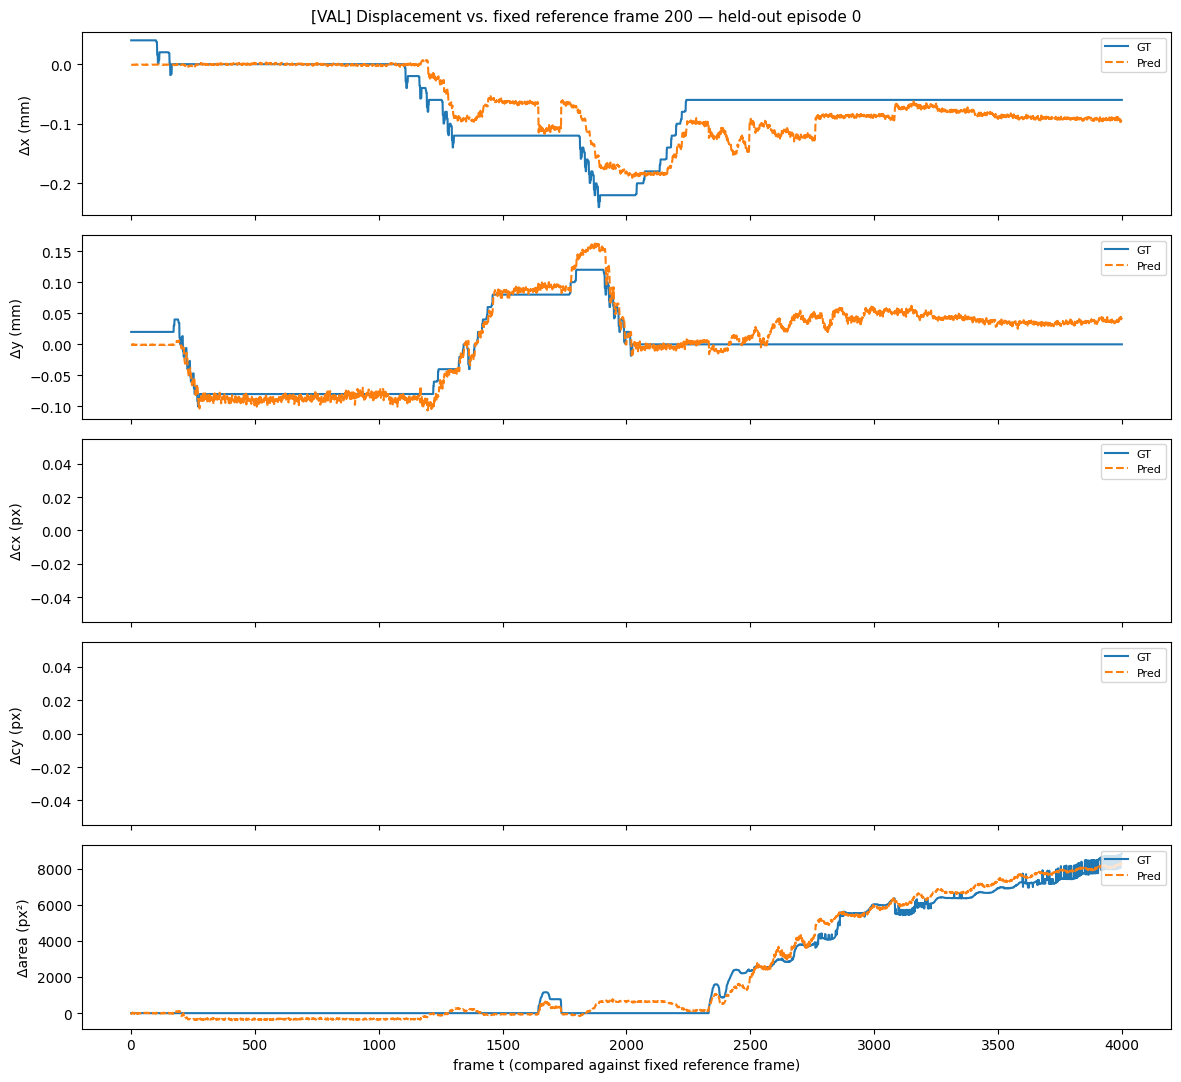

In [12]:
Q_EPISODE_DATA = val_episode_data   # VALIDATION (held-out) episode
EPISODE_IDX    = 0                  # index into Q_EPISODE_DATA
REF_FRAME_IDX  = 200                # fixed reference frame; every step compares frame t back to this one
N_STEPS        = 4000

ep = Q_EPISODE_DATA[EPISODE_IDX]
ref_found = bool(ep['ring_found'][REF_FRAME_IDX])
steps = list(range(1, min(N_STEPS, ep['n'] - 1) + 1))


def read(idx):
    with h5py.File(ep['path'], 'r') as f:
        bgr = f[f'frame_{idx}_x'][:]
    rgb = bgr[:, :, ::-1].copy()
    return to_float(torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).to(device))


all_preds_seq, all_gt_seq, all_mask_seq = [], [], []

with torch.no_grad():
    f_ref = read(REF_FRAME_IDX)
    for t in tqdm(steps, desc='Sequence eval'):
        ft       = read(t)
        emb      = extract_embedding(f_ref, ft)
        pred_raw = denormalize_target(head(emb)).squeeze(0).cpu().numpy()
        gt_xy    = (ep['xyz'][t, :2] - ep['xyz'][REF_FRAME_IDX, :2]).numpy()
        gt_ring  = (ep['ring'][t] - ep['ring'][REF_FRAME_IDX]).numpy()
        gt       = np.concatenate([gt_xy, gt_ring])
        cxcy_valid = ref_found and bool(ep['ring_found'][t])
        mask     = np.array([1., 1., float(cxcy_valid), float(cxcy_valid), 1.])
        all_preds_seq.append(pred_raw)
        all_gt_seq.append(gt)
        all_mask_seq.append(mask)

all_preds_seq = np.stack(all_preds_seq)
all_gt_seq    = np.stack(all_gt_seq)
all_mask_seq  = np.stack(all_mask_seq).astype(bool)

print('Step-wise MAE per axis — held-out validation file (Δcx/Δcy over steps with a ring in both frames only):')
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = all_mask_seq[:, i]
    mae = np.abs(all_preds_seq[valid, i] - all_gt_seq[valid, i]).mean()
    print(f'  {name}: {mae:.3f} {unit}   (n={valid.sum()}/{len(valid)})')

fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharex=True)
for i, (name, unit) in enumerate(zip(AXIS_NAMES, AXIS_UNITS)):
    valid = all_mask_seq[:, i]
    gt_plot   = np.where(valid, all_gt_seq[:, i], np.nan)
    pred_plot = np.where(valid, all_preds_seq[:, i], np.nan)
    axes[i].plot(steps, gt_plot,   label='GT',   lw=1.5)
    axes[i].plot(steps, pred_plot, label='Pred', lw=1.5, linestyle='--')
    axes[i].set_ylabel(f'Δ{name} ({unit})')
    axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('frame t (compared against fixed reference frame)')
plt.suptitle(f'[VAL] Displacement vs. fixed reference frame {REF_FRAME_IDX} — held-out episode {EPISODE_IDX}', fontsize=11)
plt.tight_layout()
plt.show()